[*********************100%***********************]  1 of 1 completed


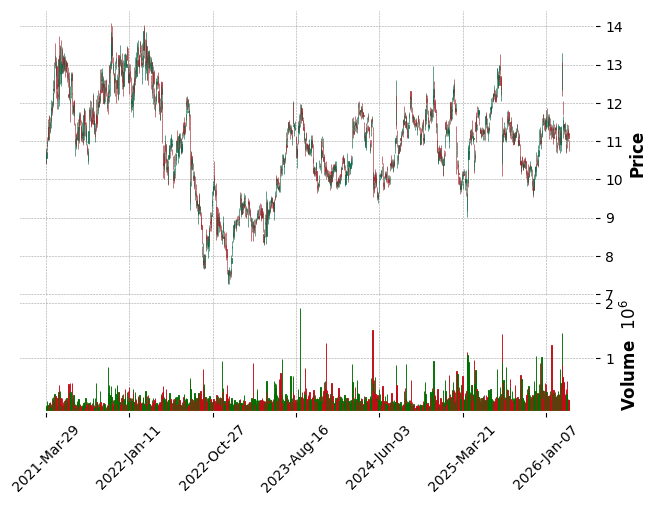

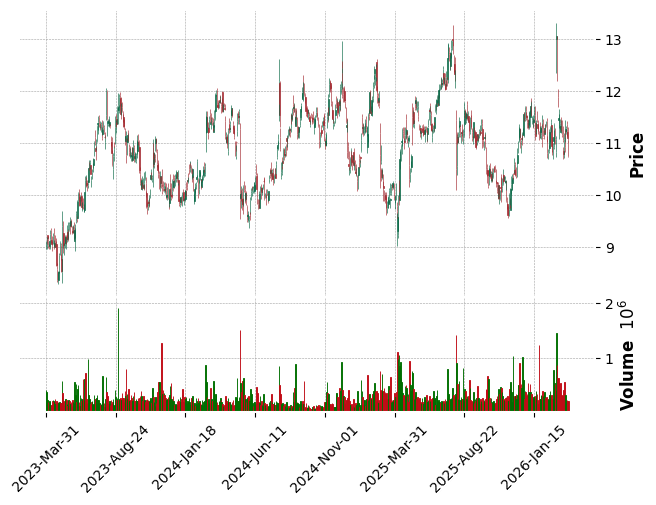

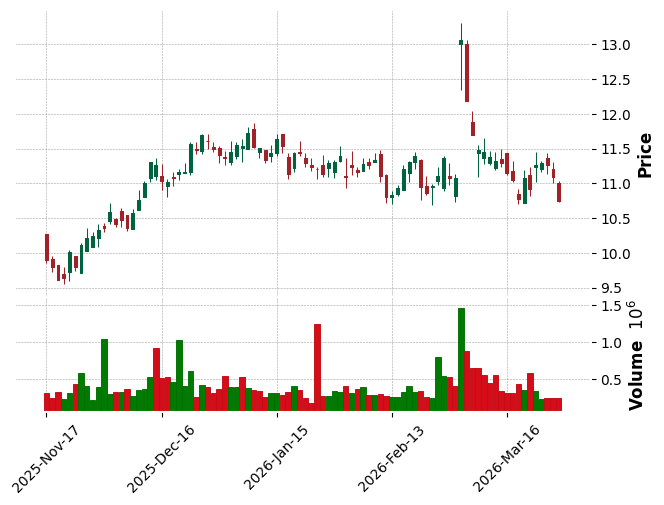

In [1]:
%load_ext autoreload
%autoreload 1
%aimport fundamentals

import finnhub
import pandas as pd
import json
from fundamentals import Fundamentals
import numpy as np
from itables import init_notebook_mode, options
import seaborn as sns
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import mplfinance as mpf
import ipynbname
init_notebook_mode(all_interactive=True)
options.style = "table-layout:auto; width:50%;"
plt.style.use('dark_background')
pd.set_option('display.float_format', '{:.2f}'.format)

# Setup client
# ASIX
name = ipynbname.name().strip('.ipynb').upper()
thirtyday = dt.datetime.now() - dt.timedelta(days=90)
Fun = Fundamentals(name, thirtyday.strftime('%Y-%m-%d'), dt.datetime.now().strftime('%Y-%m-%d'))

historical = Fun.get_history()
historical.columns = historical.columns.get_level_values(0)
mpf.plot(historical, type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-750:], type='candle', style='charles',volume=True,warn_too_much_data=10000000)
mpf.plot(historical.iloc[-90:], type='candle', style='charles',volume=True)

In [2]:
funds = Fun.get_fundamentals()

funds

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


26.715555555555557


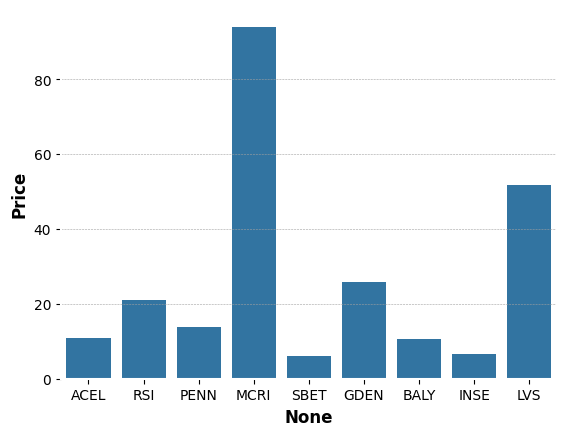

In [3]:
peers, avg_price = Fun.get_peers()
print(avg_price)
sns.barplot(x=peers.index, y=peers['Price'])
plt.show()

In [4]:
fairValues = Fun.caculateFairValues()

fairValues.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [5]:
other_metrics = Fun.get_other_metric()

other_metrics.head()

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [6]:
insider_sentiment = Fun.get_insider_sentiment()
print(f"{insider_sentiment[0]}:")
print("")
print(insider_sentiment[1])

insider_signal:

Bearish (Net Sell): -741,409 shares


In [7]:
news = Fun.get_news()

for x in news:
    print(x['datetime'])
    print(x['headline'])
    print(x['summary'])
    print(x['url'])
    print("")

2026-03-05 01:30:00
Accel Entertainment: The Chicago Jackpot
Accel Entertainment is rated 'Buy' with a new price target midpoint of $16.60, reflecting a 27.7% upside through FY 2027. Read my latest analysis of ACEL stock.
https://finnhub.io/api/news?id=ae016cfa481aaf3c4ddd9436fb2ea72dc2caa4da2613a7ba1d3dc8450594ec7a

2026-03-04 06:06:40
Accel Entertainment, Inc. 2025 Q4 - Results - Earnings Call Presentation
2026-03-04. The following slide deck was published by Accel Entertainment, Inc.
https://finnhub.io/api/news?id=5fdc9b5668a36c65859df6da0f954e1d82a797fff7e184e3bbd945be146f29ba

2026-03-04 05:13:34
Accel Entertainment shares are trading higher after the company announced better-than-expected Q4 financial results. Also, Citizens and Truist Securities raised their respective price targets on the stock.

https://finnhub.io/api/news?id=e9ee9bfd1d4b8cda5b638a1e5d1902fae58b06525e137f3b153c6f4a49e7c66c

2026-03-04 04:00:35
Latham Group, Babcock & Wilcox, B&G Foods And Other Big Stocks Movi

Average Weighted EPS: 0.1056
Lower Standard Deviation: -0.07115644767848886
Upper Standard Deviation: 0.2823564476784889
Total Debt/Total Equity: 2.2523


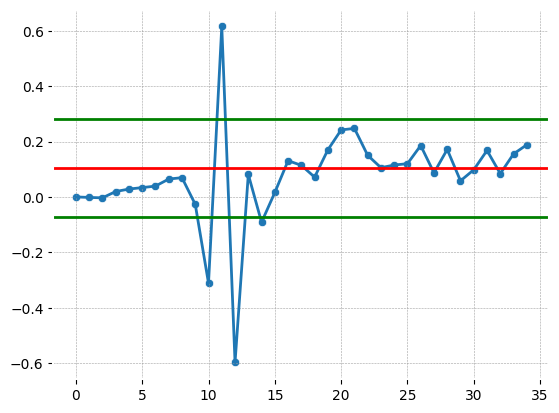

In [8]:
inflect = Fun.get_inflections()

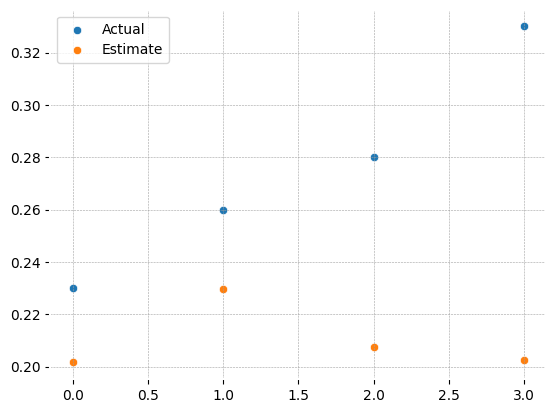

In [9]:
surprise = Fun.eps_surprise()

2021-12-31             NaN
2022-12-31    969797000.00
2023-12-31   1170420000.00
2024-12-31   1230972000.00
2025-12-31   1330960000.00
Name: Total Revenue, dtype: float64
Revenue: [4.243850e+08 7.347070e+08 9.697970e+08 1.170420e+09 1.230972e+09
 1.330960e+09]


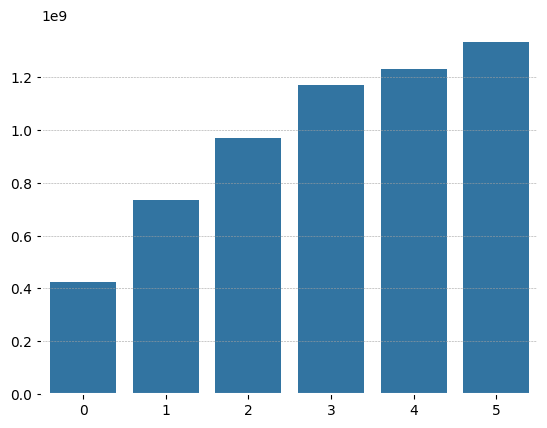

In [10]:
revenue = Fun.revenue_growth()

In [11]:
dcf = Fun.calculate_dcf()

Current FCF for ACEL: $52,502,000.00
{'Current Price': 10.75,
 'Enterprise Value': 759290166.48,
 'Intrinsic Price': 5.39,
 'Ticker': 'ACEL'}


--- Profitability Analysis: ACEL ---

Annual Net Income History:
2021-12-31           NaN
2022-12-31   74102000.00
2023-12-31   45603000.00
2024-12-31   35252000.00
2025-12-31   51470000.00
Name: Net Income, dtype: float64

Last 4 Quarters Net Income:
2025-03-31   14639000.00
2025-06-30    7315000.00
2025-09-30   13364000.00
2025-12-31   16152000.00
Name: Net Income, dtype: float64


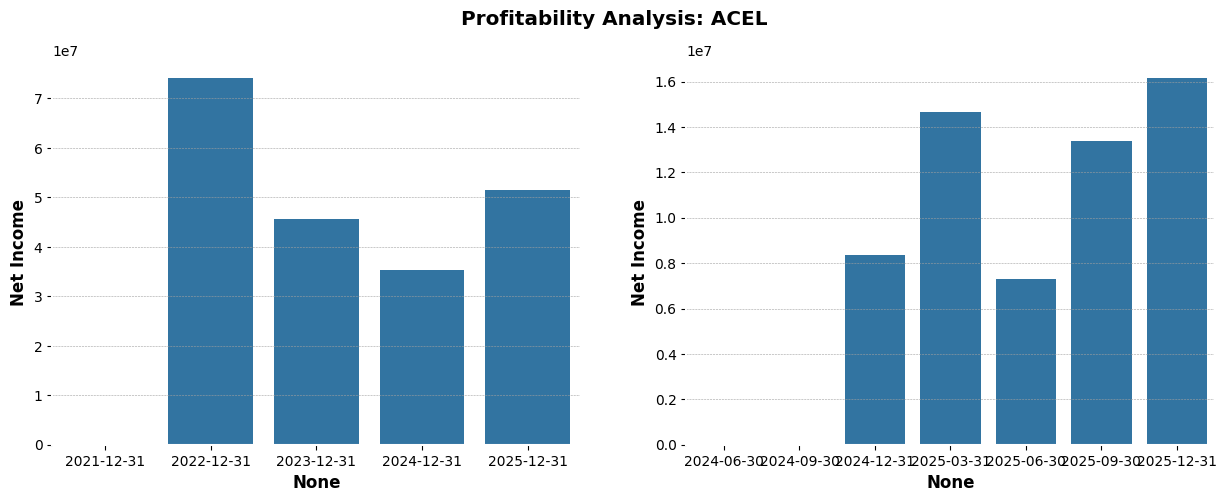

In [12]:
q, a = Fun.check_profitability()